# 1. Análise Analítica de Seção Retangular 2D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de uma estrutura retangular 2D para os modos transversos (TE e TM), analisando apenas as variações em $x$ e $y$ através dos índices $m$ e $n$.

A análise em 2D foca na frequência de corte ($f_c$) em vez da frequência de ressonância de uma cavidade fechada[cite: 6]. 

## 1.1 Frequência de Corte e Números de Onda

Para simplificar a notação e o código, introduzimos os números de onda em cada direção ($k_x$ e $k_y$), que dependem das dimensões da base e altura ($a$ e $b$)[cite: 8]:

$k_x = \frac{m\pi}{a}$
$k_y = \frac{n\pi}{b}$

O número de onda de corte ($k_c$) é dado por:
$k_c = \sqrt{k_x^2 + k_y^2}$

A frequência de corte teórica para um modo genérico $TE_{mn}$ ou $TM_{mn}$ preenchido com um dielétrico é calculada usando $k_c$:
$f_{c_{mn}} = \frac{c}{2\pi\sqrt{\mu_r\epsilon_r}} k_c$

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc

class SecaoRetangular2D:
    def __init__(self, a, b, er=1.0):
        """
        Inicializa os parâmetros da seção transversal 2D.
        a, b: Largura e altura em metros
        er: Permissividade relativa do dielétrico
        """
        self.a = a
        self.b = b
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
    def k_xy(self, m, n):
        """Calcula os números de onda kx, ky e kc."""
        kx = (m * np.pi) / self.a
        ky = (n * np.pi) / self.b
        kc = np.sqrt(kx**2 + ky**2)
        return kx, ky, kc

    def freq_corte(self, m, n):
        """Calcula a frequência de corte analítica para o modo m,n."""
        kx, ky, kc = self.k_xy(m, n)
        fc = (self.c / (2 * np.pi)) * kc
        return fc

print("Classe SecaoRetangular2D e bibliotecas carregadas!")

Classe SecaoRetangular2D e bibliotecas carregadas!


## 1.2 Distribuição do Campo Elétrico Transversal

As componentes do campo elétrico variam espacialmente segundo funções trigonométricas impostas pelas condições de contorno nas paredes metálicas[cite: 10]. 

Em vez de usar as frações dimensionais extensas, substituímos as dependências por $k_x$ e $k_y$. Para os modos $TE_{mn}$, o campo elétrico no plano bidimensional é proporcional a[cite: 12]:

$E_x \propto -k_y \cos(k_x x) \sin(k_y y)$
$E_y \propto k_x \sin(k_x x) \cos(k_y y)$

Para modos $TM_{mn}$, as equações transversais são:
$E_x \propto -k_x \cos(k_x x) \sin(k_y y)$
$E_y \propto -k_y \sin(k_x x) \cos(k_y y)$
$E_z \propto \sin(k_x x) \sin(k_y y)$

A intensidade total do campo transversal para visualização no mapa de calor é calculada pelo módulo do vetor no plano XY[cite: 13, 14]:
$|E| = \sqrt{|E_x|^2 + |E_y|^2}$

In [55]:
def plotar_geometria_2d(secao, ax=None):
    """Plota a estrutura 2D (seção transversal) no eixo fornecido ou em uma nova figura."""
    mostra_plot = False
    if ax is None:
        plt.figure(figsize=(6,4))
        ax = plt.gca()
        mostra_plot = True
        
    retangulo = patches.Rectangle((0, 0), secao.a, secao.b, linewidth=2, edgecolor='darkcyan', facecolor='cyan', alpha=0.3)
    ax.add_patch(retangulo)
    
    ax.set_title("Geometria da Seção Transversal")
    ax.set_xlabel('Largura (a) [m]')
    ax.set_ylabel('Altura (b) [m]')
    ax.set_xlim(-secao.a*0.1, secao.a*1.1)
    ax.set_ylim(-secao.b*0.1, secao.b*1.1)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    if mostra_plot:
        plt.show()

def plotar_painel_modos_TM(secao):
    """
    Gera um painel 2x3 replicando o visual de geometria e modos TM normalizados (0 a 1).
    """
    a = secao.a
    b = secao.b
    
    # Malha 2D 
    x = np.linspace(0, a, 150)
    y = np.linspace(0, b, 150)
    X, Y = np.meshgrid(x, y)
    
    # Lista dos modos TM (m, n)
    modos = [(1, 1), (2, 1), (3, 1), (1, 2), (2, 2)]
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten() 
    
    # 1. Gráfico da Geometria
    plotar_geometria_2d(secao, ax=axs[0])
    axs[0].set_title("Geometria da Seção Transversal - TM")
    
    # Definindo os níveis de cor fixos de 0 a 1
    niveis_cor = np.linspace(0, 1, 21)
    
    # 2. Gráficos dos Campos Ez Normalizados
    for i, (m, n) in enumerate(modos):
        ax = axs[i+1] 
        
        # Equação analítica COM VALOR ABSOLUTO para normalizar de 0 a 1
        Ez = np.abs(np.sin(m * np.pi * X / a) * np.sin(n * np.pi * Y / b))
        
        # Travando o vmin e vmax entre 0 e 1
        cf = ax.contourf(X, Y, Ez, levels=niveis_cor, cmap='jet', vmin=0, vmax=1)
        
        fig.colorbar(cf, ax=ax)
        
        ax.set_title(f"TM_{m}{n}", fontsize=14)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_xlim(0, a)
        ax.set_ylim(0, b)
        
    plt.tight_layout()
    plt.show()

def plotar_painel_modos_TE(secao):
    """
    Gera um painel 2x3 replicando o visual de geometria e modos TE normalizados (0 a 1).
    """
    a = secao.a
    b = secao.b
    
    # Malha 2D 
    x = np.linspace(0, a, 150)
    y = np.linspace(0, b, 150)
    X, Y = np.meshgrid(x, y)
    
    # Lista dos modos TE (m, n) 
    modos = [(1, 0), (0, 1), (2, 0), (1, 1), (2, 1)]
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten() 
    
    # 1. Gráfico da Geometria
    plotar_geometria_2d(secao, ax=axs[0])
    axs[0].set_title("Geometria da Seção Transversal - TE")
    
    # Definindo os níveis de cor fixos de 0 a 1
    niveis_cor = np.linspace(0, 1, 21)
    
    # 2. Gráficos dos Campos Hz Normalizados
    for i, (m, n) in enumerate(modos):
        ax = axs[i+1] 
        
        # Equação analítica COM VALOR ABSOLUTO para normalizar de 0 a 1
        Hz = np.abs(np.cos(m * np.pi * X / a) * np.cos(n * np.pi * Y / b))
        
        # Travando o vmin e vmax entre 0 e 1
        cf = ax.contourf(X, Y, Hz, levels=niveis_cor, cmap='jet', vmin=0, vmax=1)
        
        fig.colorbar(cf, ax=ax)
        
        ax.set_title(f"TE_{m}{n}", fontsize=14)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_xlim(0, a)
        ax.set_ylim(0, b)
        
    plt.tight_layout()
    plt.show()

## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas dimensões e escolhemos o modo desejado para calcular a frequência de corte e visualizar o campo.

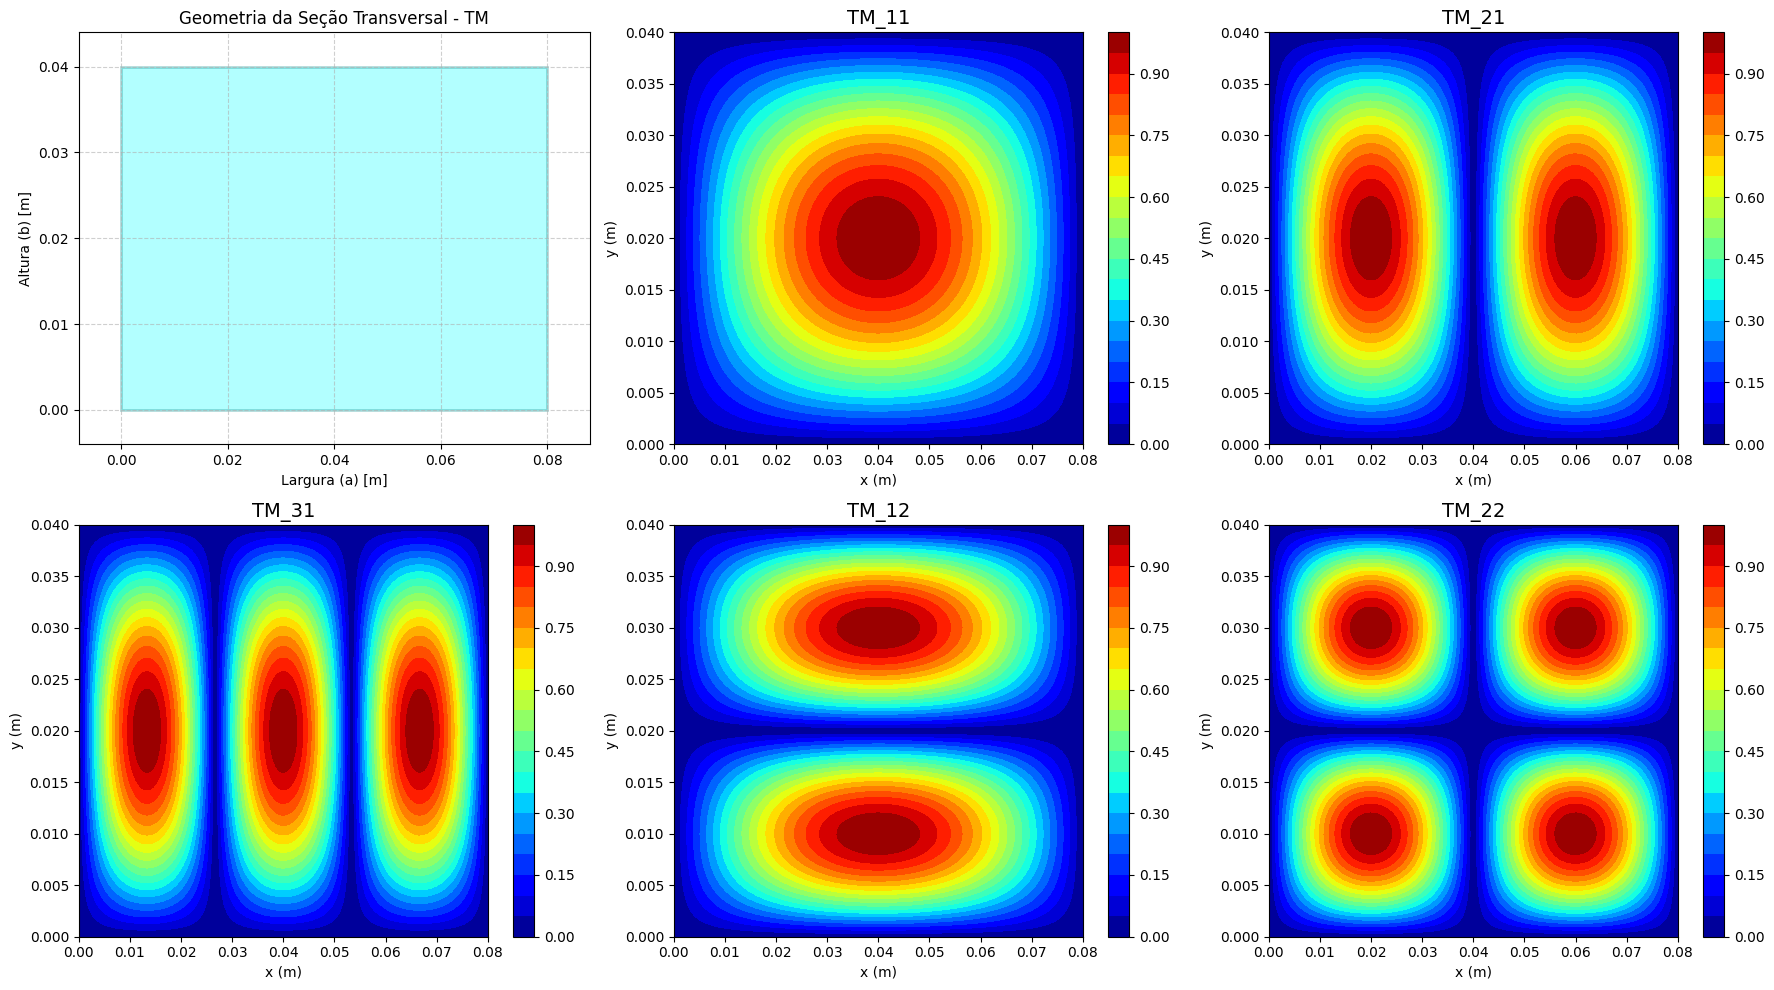

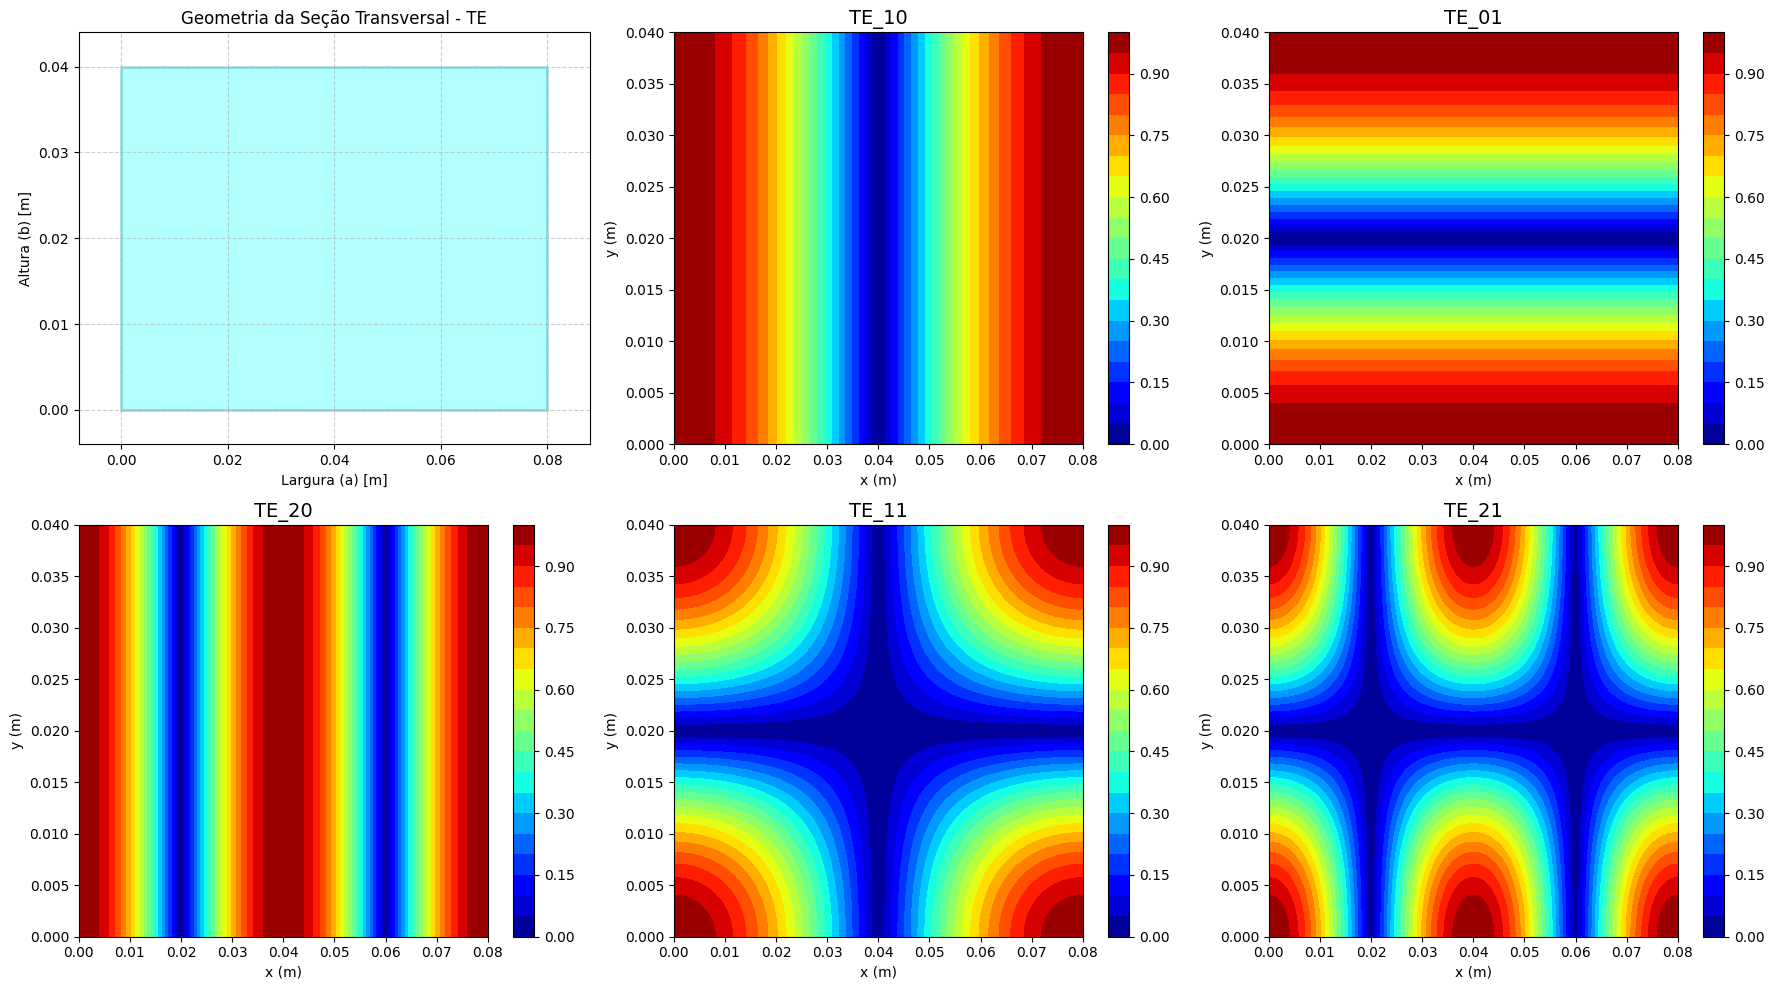

In [ ]:
# 1. Definições da Seção Transversal (Corrigido para a > b)
a_cm, b_cm = 8, 4
er_val = 1

# Instanciando o objeto
secao_2d = SecaoRetangular2D(a=a_cm * sc.centi, b=b_cm * sc.centi, er=er_val)

# 4. Executando com as dimensões da imagem que você enviou (a=0.08m, b=0.04m)
plotar_painel_modos_TM(secao_2d)
plotar_painel_modos_TE(secao_2d) 